# `Isolation Forest For Anomaly Detection`

In [6]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

In [7]:

# Generate normal data
X, _ = make_blobs(n_samples=1000, centers=2, cluster_std=1.0, random_state=42)


In [8]:
X

array([[-1.67350551,  7.88457927],
       [ 6.31757965,  1.41958144],
       [ 3.54360375,  0.5331188 ],
       ...,
       [ 3.26797769,  0.35960829],
       [ 5.76592909,  1.92177596],
       [-0.31939469,  8.20598784]], shape=(1000, 2))

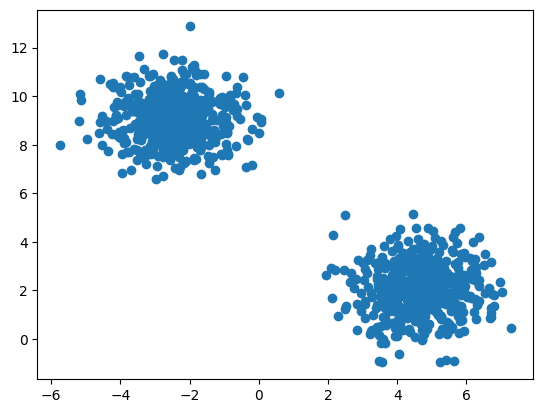

In [9]:
plt.scatter(X[:,0],X[:,1])

### Let's add some Noise/Outlier with Data

In [10]:
rng = np.random.RandomState(42)
anomalies = rng.uniform(low=-10, high=15, size=(50, 2))


In [11]:

# Combine dataset
X_full = np.vstack([X, anomalies])

In [12]:
# Labels (optional, for evaluation)
labels = np.hstack([np.zeros(len(X)), np.ones(len(anomalies))])

In [13]:
# Create DataFrame
df = pd.DataFrame(X_full, columns=['feature1', 'feature2'])
df['label'] = labels

In [14]:
df

,feature1,feature2,label
0,-1.673506,7.884579,0.0
1,6.317580,1.419581,0.0
2,3.543604,0.533119,0.0
3,5.162714,1.399470,0.0
4,4.459399,5.166277,0.0
...,...,...,...
1045,-7.010144,7.831120,1.0
1046,9.019626,4.031930,1.0
1047,9.274179,2.344890,1.0
1048,3.068321,0.688525,1.0


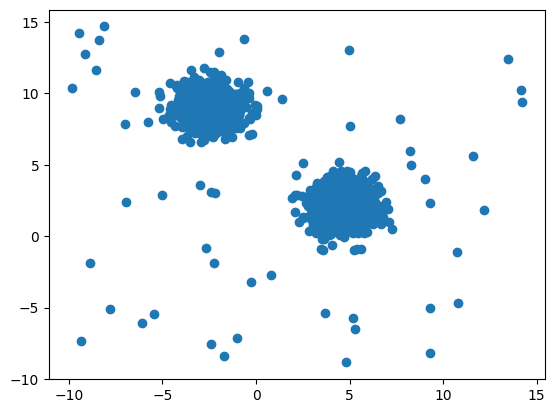

In [16]:
plt.scatter(df['feature1'],df['feature2'])

In [ ]:

# Save to CSV
df.to_csv("anomaly_dataset.csv", index=False)



In [20]:
df = pd.read_csv('anomaly_dataset.csv')
df.sample(5)

,feature1,feature2,label
185,-2.851885,8.642845,0.0
586,3.077333,1.444117,0.0
958,6.253590,2.426704,0.0
675,-3.369611,8.629731,0.0
987,5.950188,3.368853,0.0


In [21]:
from sklearn.ensemble import IsolationForest

In [22]:
clf = IsolationForest(contamination=0.05)
clf.fit(df[['feature1','feature2']])
predictions = clf.predict(df[['feature1','feature2']])

In [23]:
predictions

array([ 1,  1,  1, ..., -1,  1, -1], shape=(1050,))

## Normal data points =` 1` 
## Outliers are : `-1`

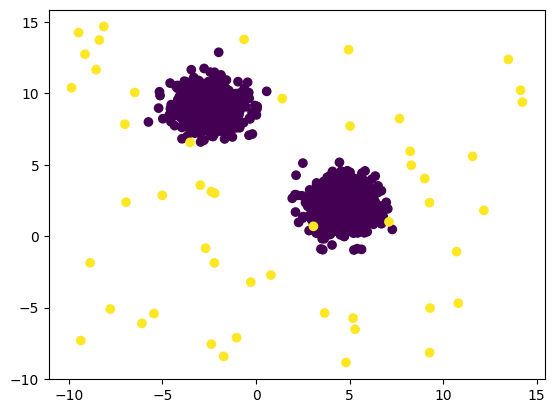

In [24]:
plt.scatter(df['feature1'],df['feature2'],c=df['label'])

### With Isolation Forest the outliers are below.

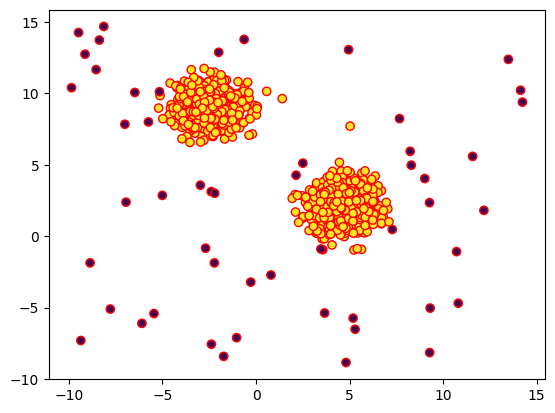

In [35]:
plt.scatter(df['feature1'],df['feature2'],c=predictions,edgecolors='red')
plt.show()

### To get the `index of Anomally`

In [ ]:
index = np.where(predictions <0)

(array([  12,   85,  182,  418,  479,  626,  827,  856, 1000, 1001, 1002,
        1003, 1005, 1006, 1007, 1008, 1009, 1010, 1011, 1013, 1014, 1015,
        1016, 1017, 1018, 1020, 1021, 1023, 1024, 1025, 1026, 1027, 1028,
        1029, 1030, 1031, 1032, 1033, 1034, 1035, 1036, 1037, 1038, 1039,
        1040, 1041, 1042, 1043, 1044, 1045, 1046, 1047, 1049]),)